 ### Transformer深入浅出

 😋😋公众号算法美食屋后台回复关键词：**torchkeras**，获取本文notebook源代码。

 前方干货预警：这可能是你能够找到的最容易懂的最具实操性的学习transformer模型入门教程。



 我们从零开始用pytorch搭建Transformer模型(中文可以翻译成`变形金刚`)。



 训练它来实现一个有趣的实例：两数之和。



 输入输出类似如下：



 输入："<SOS>12345+54321<EOS>"

 输出："<SOS>66666<EOS>"



 我们把这个任务当做一个机器翻译任务来进行。输入是一个字符序列，输出也是一个字符序列(seq-to-seq).



 这和机器翻译的输入输出结构是类似的，所以可以用Transformer来做。



 参考资料：



 论文《Attention is All you needed》: https://arxiv.org/pdf/1706.03762.pdf



 哈佛博客：https://github.com/harvardnlp/annotated-transformer/





In [1]:
import warnings
warnings.filterwarnings('ignore')  # +忽略警告信息，避免输出过多干扰内容



In [2]:
!pip install plotly seaborn accelerate

Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [3]:
import plotly.express as px  # +导入plotly可视化库，用于绘制交互式图表

In [4]:
import matplotlib.pyplot as plt  # +导入matplotlib的pyplot模块，用于基础绘图
import seaborn as sns  # +导入seaborn库，用于美化图表样式
sns.set(rc = {'figure.figsize':(15,15)})  # +设置图表默认大小



 ## 一，准备数据

In [5]:
import random  # +导入随机数模块，用于生成随机数据

import numpy as np  # +导入numpy库，用于数值计算
import torch  # +导入PyTorch库，用于构建和训练模型
from torch.utils.data import Dataset,DataLoader  # +导入数据集和数据加载器相关类

# 定义字典
words_x = '<PAD>,1,2,3,4,5,6,7,8,9,0,<SOS>,<EOS>,+'  # +输入序列包含的字符集，包括数字、特殊符号
vocab_x = {word: i for i, word in enumerate(words_x.split(','))}  # +构建输入字符到索引的映射字典
vocab_xr = [k for k, v in vocab_x.items()] #反查词典  # +构建输入索引到字符的反查列表，用于解码

words_y = '<PAD>,1,2,3,4,5,6,7,8,9,0,<SOS>,<EOS>'  # +输出序列包含的字符集，相比输入少了'+'
vocab_y = {word: i for i, word in enumerate(words_y.split(','))}  # +构建输出字符到索引的映射字典
vocab_yr = [k for k, v in vocab_y.items()] #反查词典  # +构建输出索引到字符的反查列表，用于解码



In [6]:
#两数相加数据集
def get_data():
    # 定义词集合
    words = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']  # +数字字符集

    # 每个词被选中的概率
    p = np.array([7, 5, 5, 7, 6, 5, 7, 6, 5, 7])  # +自定义每个数字被选中的概率权重
    p = p / p.sum()  # +归一化概率，使其和为1

    # 随机采样n1个词作为s1
    n1 = random.randint(10, 20)  # +随机生成第一个数字的长度（10到20位）
    s1 = np.random.choice(words, size=n1, replace=True, p=p)  # +根据概率采样生成第一个数字的字符序列
    s1 = s1.tolist()  # +转换为列表

    # 随机采样n2个词作为s2
    n2 = random.randint(10, 20)  # +随机生成第二个数字的长度（10到20位）
    s2 = np.random.choice(words, size=n2, replace=True, p=p)  # +根据概率采样生成第二个数字的字符序列
    s2 = s2.tolist()  # +转换为列表

    # x等于s1和s2字符上的相加
    x = s1 + ['+'] + s2  # +构建输入序列：第一个数字+加号+第二个数字
    
    # y等于s1和s2数值上的相加
    y = int(''.join(s1)) + int(''.join(s2))  # +计算两个数字的和
    y = list(str(y))  # +将和转换为字符列表
    
    # 加上首尾符号
    x = ['<SOS>'] + x + ['<EOS>']  # +给输入序列添加起始符<SOS>和结束符<EOS>
    y = ['<SOS>'] + y + ['<EOS>']  # +给输出序列添加起始符<SOS>和结束符<EOS>

    # 补pad到固定长度
    x = x + ['<PAD>'] * 50  # +用<PAD>填充输入序列
    y = y + ['<PAD>'] * 51  # +用<PAD>填充输出序列
    x = x[:50]  # +截断输入序列到固定长度50
    y = y[:51]  # +截断输出序列到固定长度51

    # 编码成token
    token_x = [vocab_x[i] for i in x]  # +将输入字符序列转换为索引序列
    token_y = [vocab_y[i] for i in y]  # +将输出字符序列转换为索引序列

    # 转tensor
    tensor_x = torch.LongTensor(token_x)  # +转换为PyTorch张量（长整型）
    tensor_y = torch.LongTensor(token_y)  # +转换为PyTorch张量（长整型）
    return tensor_x, tensor_y  # +返回生成的输入和输出张量


def show_data(tensor_x,tensor_y) ->"str":
    # +将输入张量解码为字符序列
    words_x = "".join([vocab_xr[i] for i in tensor_x.tolist()])
    # +将输出张量解码为字符序列
    words_y = "".join([vocab_yr[i] for i in tensor_y.tolist()])
    return words_x,words_y  # +返回解码后的字符串


x,y = get_data()  # +生成一组数据
print(x,y,"\n")  # +打印张量形式的数据
print(show_data(x,y))  # +打印解码后的字符串形式的数据



tensor([11,  6,  5, 10,  6,  3,  2,  3,  6, 10,  6,  9,  2,  1,  4,  6,  9,  9,
         9,  7, 13,  6,  7,  2,  4, 10,  1,  1,  4,  7,  1,  7,  5,  5, 12,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]) tensor([11,  6,  5, 10,  6,  3,  3, 10,  3,  3, 10,  9,  3,  2,  9,  4,  1,  7,
         5,  2, 12,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]) 

('<SOS>6506323606921469997+6724011471755<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>', '<SOS>6506330330932941752<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>')


In [7]:
# 定义数据集
class TwoSumDataset(torch.utils.data.Dataset):
    def __init__(self,size = 100000):
        super(Dataset, self).__init__()  # +调用父类构造函数
        self.size = size  # +数据集大小

    def __len__(self):
        return self.size  # +返回数据集大小

    def __getitem__(self, i):
        return get_data()  # +根据索引返回一组数据（通过调用get_data生成）
    
ds_train = TwoSumDataset(size = 100000)  # +创建训练数据集，包含100000个样本
ds_val = TwoSumDataset(size = 10000)  # +创建验证数据集，包含10000个样本


# 数据加载器
dl_train = DataLoader(dataset=ds_train,
         batch_size=200,  # +批次大小为200
         drop_last=True,  # +丢弃最后一个不完整的批次
         shuffle=True)  # +打乱数据顺序

dl_val = DataLoader(dataset=ds_val,
         batch_size=200,  # +批次大小为200
         drop_last=True,  # +丢弃最后一个不完整的批次
         shuffle=False)  # +不打乱数据顺序



In [8]:
for src,tgt in dl_train:
    print(src.shape)  # +打印输入张量的形状
    print(tgt.shape)  # +打印输出张量的形状
    break  # +只打印第一个批次的信息



torch.Size([200, 50])
torch.Size([200, 51])


 ## 二，定义模型

 下面，我们会像搭积木建城堡那样从低往高地构建Transformer模型。



 先构建6个基础组件：多头注意力、前馈网络、层归一化、残差连接、单词嵌入、位置编码。类似用最基础的积木块搭建了 墙壁，屋顶，篱笆，厅柱，大门，窗户 这样的模块。



 然后用这6个基础组件构建了3个中间成品: 编码器，解码器，产生器。类似用基础组件构建了城堡的主楼，塔楼，花园。



 最后用这3个中间成品组装成Tranformer完整模型。类似用主楼，塔楼，花园这样的中间成品拼凑出一座完整美丽的城堡。



 1, 多头注意力: MultiHeadAttention (用于融合不同单词之间的信息, 三处使用场景，①Encoder self-attention, ② Decoder masked-self-attention, ③ Encoder-Decoder cross-attention)



 2, 前馈网络: PositionwiseFeedForward (用于逐位置将多头注意力融合后的信息进行高维映射变换，简称FFN)



 3, 层归一化: LayerNorm (用于稳定输入，每个样本在Sequece和Feature维度归一化,相比BatchNorm更能适应NLP领域变长序列)



 4, 残差连接: ResConnection (用于增强梯度流动以降低网络学习难度, 可以先LayerNorm再Add，LayerNorm也可以放在残差Add之后)



 5, 单词嵌入: WordEmbedding (用于编码单词信息，权重要学习，输出乘了sqrt(d_model)来和位置编码保持相当量级)



 6, 位置编码: PositionEncoding (用于编码位置信息，使用sin和cos函数直接编码绝对位置)



 **************************************************************************************************************



 7, 编码器: TransformerEncoder (用于将输入Sequence编码成与Sequence等长的memory向量序列, 由N个TransformerEncoderLayer堆叠而成)



 8, 解码器: TransformerDecoder (用于将编码器编码的memory向量解码成另一个不定长的向量序列, 由N个TransformerDecoderLayer堆叠而成)



 9, 生成器: Generator (用于将解码器解码的向量序列中的每个向量映射成为输出词典中的词，一般由一个Linear层构成)



 *************************************************************************************************************



 10, 变形金刚: Transformer (用于Seq2Seq转码，例如用于机器翻译，采用EncoderDecoder架构，由Encoder, Decoder 和 Generator组成)





In [9]:
import torch  # +再次导入PyTorch库（确保可用）
from torch import nn  # +导入PyTorch的神经网络模块
import torch.nn.functional as F  # +导入PyTorch的函数式接口
import copy  # +导入copy模块，用于对象复制
import math  # +导入math模块，用于数学运算
import numpy as np  # +再次导入numpy库
import pandas as pd  # +导入pandas库，用于数据处理

def clones(module, N):
    "Produce N identical layers."
    # +创建N个相同的模块副本，组成ModuleList
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])



 ### 1，多头注意力 MultiHeadAttention



 需要逐步理解 ScaledDotProductAttention->MultiHeadAttention->MaskedMultiHeadAttention



 先理解什么是 ScaledDotProductAttention，再理解MultiHeadAttention， 然后理解MaskedMultiHeadAttention





In [10]:
class ScaledDotProductAttention(nn.Module):
    "Compute 'Scaled Dot Product Attention'"
    def __init__(self):
        super(ScaledDotProductAttention, self).__init__()  # +调用父类构造函数

    def forward(self,query, key, value, mask=None, dropout=None):
        d_k = query.size(-1)  # +获取每个注意力头的维度
        # +计算注意力分数：Q和K的转置相乘，再除以sqrt(d_k)进行缩放
        scores = query@key.transpose(-2,-1) / math.sqrt(d_k)     
        if mask is not None:
            # +应用掩码：将掩码为0的位置的分数设为极小值（-1e20），使softmax后接近0
            scores = scores.masked_fill(mask == 0, -1e20)
        p_attn = F.softmax(scores, dim = -1)  # +对最后一维进行softmax，得到注意力概率分布
        if dropout is not None:
            p_attn = dropout(p_attn)  # +应用dropout，防止过拟合
        # +注意力概率分布与V相乘，得到输出；同时返回注意力概率
        return p_attn@value, p_attn
    
class MultiHeadAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "Take in model size and number of heads."
        super(MultiHeadAttention, self).__init__()  # +调用父类构造函数
        assert d_model % h == 0  # +确保模型维度能被头数整除
        # We assume d_v always equals d_k
        self.d_k = d_model // h  # +每个注意力头的维度
        self.h = h  # +注意力头的数量
        # +创建4个线性层（Q、K、V的投影各一个，最后输出投影一个）
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None  # +记录注意力矩阵结果
        self.dropout = nn.Dropout(p=dropout)  # +dropout层
        self.attention = ScaledDotProductAttention()  # +实例化缩放点积注意力模块
        
    def forward(self, query, key, value, mask=None):
        if mask is not None:
            # Same mask applied to all h heads.
            mask = mask.unsqueeze(1)  # +在头维度上增加一个维度，使掩码能应用到所有头
        nbatches = query.size(0)  # +获取批次大小
        
        # 1) Do all the linear projections in batch from d_model => h x d_k 
        # +对Q、K、V进行线性投影，并重塑为（批次，头数，序列长度，每个头的维度）
        query, key, value = [
            l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
             for l, x in zip(self.linears, (query, key, value))
        ]
        
        # 2) Apply attention on all the projected vectors in batch. 
        # +应用缩放点积注意力
        x, self.attn = self.attention(query, key, value, mask=mask, 
                                 dropout=self.dropout)
        
        # 3) "Concat" using a view and apply a final linear. 
        # +将多个头的输出拼接起来，并通过最后一个线性层
        x = x.transpose(1, 2).contiguous() \
             .view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)  # +返回最终输出


#为了让训练过程与解码过程信息流一致，遮挡tgt序列后面元素，设置其注意力为0
def tril_mask(data):
    "Mask out future positions."
    size = data.size(-1)  # +获取序列长度
    # +创建一个全1的矩阵，大小为（1，序列长度，序列长度）
    full = torch.full((1,size,size),1,dtype=torch.int,device=data.device)
    mask = torch.tril(full).bool()  # +取下三角矩阵，并转换为布尔类型（下三角为True，上三角为False）
    return mask  # +返回掩码


#设置对<PAD>的注意力为0
def pad_mask(data, pad=0):
    "Mask out pad positions."
    # +创建一个掩码，非PAD位置为True，PAD位置为False，形状为（批次，1，序列长度）
    mask = (data!=pad).unsqueeze(-2)
    return mask  # +返回掩码


#计算一个batch数据的src_mask和tgt_mask
class MaskedBatch:
    "Object for holding a batch of data with mask during training."
    def __init__(self, src, tgt=None, pad=0):
        self.src = src  # +输入序列
        self.src_mask = pad_mask(src,pad)  # +输入序列的PAD掩码
        if tgt is not None:
            # +训练时，目标序列的输入是除了最后一个元素的部分（用于预测下一个元素）
            self.tgt = tgt[:,:-1]
            # +训练时，目标序列的标签是除了第一个元素的部分（从第二个元素开始预测）
            self.tgt_y = tgt[:, 1:]
            # +创建目标序列的掩码（同时考虑PAD和未来信息）
            self.tgt_mask = \
                self.make_tgt_mask(self.tgt, pad)
            # +计算非PAD标签的数量（用于损失计算）
            self.ntokens = (self.tgt_y!= pad).sum() 
    
    @staticmethod
    def make_tgt_mask(tgt, pad):
        "Create a mask to hide padding and future words."
        tgt_pad_mask = pad_mask(tgt,pad)  # +目标序列的PAD掩码
        tgt_tril_mask = tril_mask(tgt)  # +目标序列的下三角掩码（遮挡未来信息）
        tgt_mask = tgt_pad_mask & (tgt_tril_mask)  # +合并两种掩码
        return tgt_mask  # +返回合并后的掩码
    



In [11]:
# 测试tril_mask 
mask = tril_mask(torch.zeros(1,10))  # +创建序列长度为10的下三角掩码
#sns.heatmap(mask[0],cmap=sns.cm.rocket);
px.imshow(mask[0],color_continuous_scale="blues",height=600,width=600)  # +可视化掩码



In [12]:
#测试 ScaledDotProductAttention

# +创建测试用的query、key、value张量（形状：1x5x2）
query = torch.tensor([[[0.0,1.414],[1.414,0.0],[1.0,1.0],[-1.0,1.0],[1.0,-1.0]]])
key = query.clone()  # +key与query相同
value = query.clone()  # +value与query相同

attention = ScaledDotProductAttention()  # +实例化缩放点积注意力

#没有mask 
out,p_att = attention(query, key, value)  # +不使用掩码计算注意力
# +可视化注意力矩阵
fig = px.imshow(p_att[0],color_continuous_scale="blues",
                title="without mask",height=600,width=600)
fig.show() 


In [13]:
#考虑mask
# +使用下三角掩码计算注意力（序列长度为5）
out,p_att = attention(query, key, value, mask = tril_mask(torch.zeros(3,5)))
# +可视化带掩码的注意力矩阵
fig = px.imshow(p_att[0],color_continuous_scale="blues",
                height=600,width=600,
                title="with mask")
fig.show() 


In [14]:
# 测试MultiHeadAttention
cross_attn = MultiHeadAttention(h=2, d_model=4)  # +实例化多头注意力（2个头，模型维度4）
cross_attn.eval()  # +设置为评估模式（关闭dropout等）
# +创建测试用的query张量（形状：1x2x4）
q1 = torch.tensor([[[0.1,0.1,0.1,0.1],[0.1,0.3,0.1,0.3]]])
k1 = q1.clone()  # +key与query相同
v1 = q1.clone()  # +value与query相同
tgt_mask = tril_mask(torch.zeros(2,2))  # +创建序列长度为2的下三角掩码

out1 = cross_attn.forward(q1,k1,v1,mask = tgt_mask)  # +应用掩码计算多头注意力
print("out1:\n",out1)  # +打印输出

#改变序列的第2个元素取值，由于有mask的遮挡，不会影响第1个输出
# +修改query的第二个元素
q2 = torch.tensor([[[0.1,0.1,0.1,0.1],[0.4,0.5,0.5,0.8]]])
k2 = q2.clone()  # +key与修改后的query相同
v2 = q2.clone()  # +value与修改后的query相同
tgt_mask = tril_mask(torch.zeros(2,2))  # +同样的掩码
out2 = cross_attn.forward(q2,k2,v2,mask = tgt_mask)  # +再次计算多头注意力
print("out2:\n",out2)  # +打印输出（观察第一个元素是否变化）



out1:
 tensor([[[-0.3085, -0.6418,  0.3580,  0.0998],
         [-0.2850, -0.6250,  0.3533,  0.0978]]], grad_fn=<ViewBackward0>)
out2:
 tensor([[[-0.3085, -0.6418,  0.3580,  0.0998],
         [-0.1568, -0.6622,  0.2822,  0.0336]]], grad_fn=<ViewBackward0>)


In [15]:
# 测试MaskedBatch
mbatch = MaskedBatch(src = src,tgt = tgt, pad = 0)  # +创建带掩码的批次对象
print(mbatch.src.shape)  # +打印输入序列形状
print(mbatch.tgt.shape)  # +打印目标输入序列形状
print(mbatch.tgt_y.shape)  # +打印目标标签序列形状

print(mbatch.src_mask.shape)  # +打印输入掩码形状
print(mbatch.tgt_mask.shape)  # +打印目标掩码形状
# +可视化目标掩码
px.imshow(mbatch.tgt_mask[0],color_continuous_scale="blues",width=600,height=600)


torch.Size([200, 50])
torch.Size([200, 50])
torch.Size([200, 50])
torch.Size([200, 1, 50])
torch.Size([200, 50, 50])


 关于Transformer的多头注意力机制，有几个要点问题，此处做一些梳理：





 (1)，Transformer是如何解决长距离依赖的问题的？



 Transformer是通过引入Scale-Dot-Product注意力机制来融合序列上不同位置的信息，从而解决长距离依赖问题。以文本数据为例，在循环神经网络LSTM结构中，输入序列上相距很远的两个单词无法直接发生交互，只能通过隐藏层输出或者细胞状态按照时间步骤一个一个向后进行传递。对于两个在序列上相距非常远的单词，中间经过的其它单词让隐藏层输出和细胞状态混入了太多的信息，很难有效地捕捉这种长距离依赖特征。但是在Scale-Dot-Product注意力机制中，序列上的每个单词都会和其它所有单词做一次点积计算注意力得分，这种注意力机制中单词之间的交互是强制的不受距离影响的，所以可以解决长距离依赖问题。





 (2)，Transformer在训练和测试阶段可以在时间(序列)维度上进行并行吗？



 在训练阶段，Encoder和Decoder在时间(序列)维度都是并行的，在测试阶段，Encoder在序列维度是并行的，Decoder是串行的。



 首先，Encoder部分在训练阶段和预测阶段都可以并行比较好理解，无论在训练还是预测阶段，它干的事情都是把已知的完整输入编码成memory，在序列维度可以并行。



 对于Decoder部分有些微妙。在预测阶段Decoder肯定是不能并行的，因为Decoder实际上是一个自回归，它前面k-1位置的输出会变成第k位的输入的。前面没有计算完，后面是拿不到输入的，肯定不可以并行。那么训练阶段能否并行呢？虽然训练阶段知道了全部的解码结果，但是训练阶段要和预测阶段一致啊，前面的解码输出不能受到后面解码结果的影响啊。但Transformer通过在Decoder中巧妙地引入Mask技巧，使得在用Attention机制做序列特征融合的时候，每个单词对位于它之后的单词的注意力得分都为0，这样就保证了前面的解码输出不会受到后面解码结果的影响，因此Decoder在训练阶段可以在序列维度做并行。





 (3)，Scaled-Dot Product Attention为什么要除以$\sqrt{d_k}$?



 为了避免$d_k$变得很大时softmax函数的梯度趋于0。假设Q和K中的取出的两个向量$q$和$k$的每个元素值都是正态随机分布，数学上可以证明两个独立的正态随机变量的积依然是一个正态随机变量，那么两个向量做点积，会得到$d_k$个正态随机变量的和，数学上$d_k$个正态随机变量的和依然是一个正态随机变量，其方差是原来的$d_k$倍，标准差是原来的$\sqrt{d_k}$倍。如果不做scale, 当$d_k$很大时，求得的$QK^T$元素的绝对值容易很大，导致落在softmax的极端区域(趋于0或者1)，极端区域softmax函数的梯度值趋于0，不利于模型学习。除以$\sqrt{d_k}$，恰好做了归一，不受$d_k$变化影响。





 (4)，MultiHeadAttention的参数数量和head数量有何关系?



 MultiHeadAttention的参数数量和head数量无关。多头注意力的参数来自对QKV的三个变换矩阵以及多头结果concat后的输出变换矩阵。假设嵌入向量的长度是d_model, 一共有h个head. 对每个head，$W_{i}^{Q},W_{i}^{K},W_{i}^{V}$ 这三个变换矩阵的尺寸都是 d_model×(d_model/h)，所以h个head总的参数数量就是3×d_model×(d_model/h)×h = 3×d_model×d_model。它们的输出向量长度都变成 d_model/h，经过attention作用后向量长度保持，h个head的输出拼接到一起后向量长度还是d_model，所以最后输出变换矩阵的尺寸是d_model×d_model。因此，MultiHeadAttention的参数数量为 4×d_model×d_model，和head数量无关。





 ### 2，前馈网络: PositionwiseFeedForward

 用于逐位置将多头注意力融合后的信息进行高维映射变换，简称FFN。



 FFN仅有两个线性层，第一层将模型向量维度 从 d_model(512) 升到 d_ff(2048), 第二层再降回 d_model(512)



 两个线性层之间加了一个0.1的Dropout





In [16]:
class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()  # +调用父类构造函数
        # +第一层线性变换：从d_model映射到d_ff
        self.linear1 = nn.Linear(d_model, d_ff)  #线性层默认作用在最后一维度
        # +第二层线性变换：从d_ff映射回d_model
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)  # +dropout层

    def forward(self, x):
        # +前向传播：线性变换->ReLU激活->dropout->线性变换
        return self.linear2(self.dropout(F.relu(self.linear1(x))))
    



 ### 3，层归一化：LayerNorm



 在视觉领域，归一化一般用BatchNorm，但是在NLP领域，归一化一般用LayerNorm。



 这是由于NLP领域的输入常常是不等长的Sequence，使用BatchNorm会让较长的Sequence输入的后面特征能够使用的参与归一化的样本数太少，让输入变得不稳定。



 同时同一个Sequence的被PADDING填充的特征也会因BatchNorm获得不同的非零值，这对模型非常不友好。



 相比之下，LayerNorm总是对一个样本自己的特征进行归一化，没有上述问题。



In [17]:
class LayerNorm(nn.Module):
    "Construct a layernorm module (similar to torch.nn.LayerNorm)."
    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()  # +调用父类构造函数
        self.weight = nn.Parameter(torch.ones(features))  # +可学习的缩放参数
        self.bias = nn.Parameter(torch.zeros(features))  # +可学习的偏移参数
        self.eps = eps  # +防止除零的小常数

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)  # +计算最后一维的均值（保持维度）
        std = x.std(-1, keepdim=True)  # +计算最后一维的标准差（保持维度）
        # +归一化：(x-mean)/(std+eps)，然后应用缩放和偏移
        return self.weight * (x - mean) / (std + self.eps) + self.bias
    



 ### 4，残差连接：ResConnection

 用于增强梯度流动以降低网络学习难度。



 ResConnection 包括LayerNorm和Add残差连接操作, LayerNorm可以放在最开始(norm_first=True)，也可以放在最后(norm_first=False)。



 《Attention is All you needed》论文原文是残差连接之后再 LayerNorm，但后面的一些研究发现最开始的时候就LayerNorm更好一些。



 残差连接对于训练深度网络至关重要。有许多研究残差连接(ResNet)作用机制，解释它为什么有效的文章，主要的一些观点如下。



 1，残差连接增强了梯度流动。直观上看，loss端的梯度能够通过跳跃连接快速传递到不同深度的各个层，增强了梯度流动，降低了网络的学习难度。数学上看，残差块的导数 f(x)=x+h(x) 为 f'(x)=1+h'(x) 在1.0附近，避免了梯度消失问题。



 2，残差连接减轻了网络退化。一个网络层h(x)可以用一个变换矩阵H来表示，由于许多神经元有相同的反应模式，h(x)等价的变换矩阵H可能有许多行是线性相关的，这使得H的行列式为0，H为非可逆矩阵，h(x)会导致网络的退化和信息丢失。但增加了残差连接之后，f(x)=x+h(x)对应的变换矩阵F=H+I，单位阵I消除了H中相关行的线性相关性，减轻了退化的可能。



 3，残差连接实现了模型集成。如果将训练好的ResNet的一些block移除，模型的预测精度并不会崩溃式下降，但是如果将训练好的VGG的一些block移除，模型的预测精度会雪崩。这说明ResNet中的各个Block类似基模型，ResNet通过残差连接将它们整合成了一个ensemble集成模型，增强了泛化能力。



 4，残差连接增强了表达能力。使用残差块构建的深层网络所代表的函数簇集合是浅层网络所代表的的函数簇集合的超集，表达能力更强，所以可以通过添加残差块不断扩充模型表达能力。 如果不使用残差连接，一个一层的网络f(x) = h1(x)  所能表示的函数簇 不一定能被一个二层的网络 f(x) = h2(h1(x))所覆盖，但是使用残差连接后，f(x) = h1(x)+h2(h1(x))一定可以覆盖一层的网络所表示的函数簇，只要h2的全部权重取0即可。



 参考：https://zhuanlan.zhihu.com/p/165350103





In [18]:
class ResConnection(nn.Module):
    """
    A residual connection with a layer norm.
    Note the norm is at last according to the paper, but it may be better at first.
    """
    def __init__(self, size, dropout, norm_first=True):
        super(ResConnection, self).__init__()  # +调用父类构造函数
        self.norm = LayerNorm(size)  # +层归一化模块
        self.dropout = nn.Dropout(dropout)  # +dropout层
        self.norm_first = norm_first  # +是否先做归一化

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        if self.norm_first:
            # +先归一化，再通过子层，应用dropout，最后与原始输入相加（残差连接）
            return x + self.dropout(sublayer(self.norm(x)))
        else:
            # +先通过子层，应用dropout，与原始输入相加，最后做归一化
            return self.norm(x + self.dropout(sublayer(x)))
        



 ### 5，单词嵌入: WordEmbedding(权重要学习)



 用于编码单词信息，权重要学习，输出乘了sqrt(d_model)来和位置编码保持相当量级。



 当d_model越大的时候，根据 nn.init.xavier_uniform 初始化策略初始化的权重取值会越小。



In [19]:
# 单词嵌入
class WordEmbedding(nn.Module):
    def __init__(self, d_model, vocab):
        super(WordEmbedding, self).__init__()  # +调用父类构造函数
        # +创建嵌入层：vocab为词汇表大小，d_model为嵌入维度
        self.embedding = nn.Embedding(vocab, d_model)
        self.d_model = d_model  # +嵌入维度

    def forward(self, x):
        # +返回嵌入向量，并乘以sqrt(d_model)进行缩放（与位置编码保持量级一致）
        return self.embedding(x) * math.sqrt(self.d_model) #note here, multiply sqrt(d_model)
    



 ### 6，位置编码：PositionEncoding(直接编码)

 PositionEncoding用于编码位置信息，使用sin和cos函数直接编码绝对位置。



 单词和单词顺序对语言意义都非常重要。



 "你欠我1000块钱"和"我欠你1000块钱"是由完全相同的单词组成，但由于词的顺序不同，含义截然相反。



 在Transformer之前，一般用RNN模型来处理句子序列。



 RNN模型本身蕴含了对顺序的建模，单词是按照它们在句子中的自然顺序一个个地被RNN单元处理，逐个地被编码。



 但Transformer是并行地处理句子中的单词的，缺少单词的位置信息表征。



 为了有效地表征单词的位置信息，Transformer设计了位置编码 PositionalEncoding，并添加到模型的输入中。



 于是，Transformer 用单词嵌入(权重要学习)向量 和位置编码(直接编码)向量 之和 来表示输入。



 如何构造位置编码呢？即如何 把 pos = 0,1,2,3,4,5,... 这样的位置序列映射成为 一个一个的向量呢?



 Transformer设计了基于正弦函数和余弦函数的位置编码方法。



 ![](https://tva1.sinaimg.cn/large/008i3skNgy1gzc6mms5h0j30hs03s74f.jpg)

 这种编码方法有以下几个优点：



 1，编码值分布在[-1,1]之间，这样的分布对神经网络是比较友好的。



 2，编码了绝对位置信息，对于0<=pos<=2*pi*10000，每个pos的位置编码向量都是不一样的。





 更多位置编码的讨论参考如下博客：



 《让研究人员绞尽脑汁的Transformer位置编码》



 https://kexue.fm/archives/8130



In [20]:
# 位置编码
class PositionEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionEncoding, self).__init__()  # +调用父类构造函数
        self.dropout = nn.Dropout(p=dropout)  # +dropout层
        
        # Compute the positional encodings once in log space.
        # +创建位置编码矩阵（max_len, d_model）
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)  # +位置索引（max_len, 1）
        # +计算衰减因子（用于控制正弦余弦函数的周期）
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        # +偶数维度用正弦函数
        pe[:, 0::2] = torch.sin(position * div_term)
        # +奇数维度用余弦函数
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # +增加批次维度（1, max_len, d_model）
        # +将位置编码注册为非参数缓冲区（不会被优化器更新）
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # +将位置编码添加到输入中（取与输入序列长度匹配的部分）
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)  # +应用dropout
    



In [21]:
pe = PositionEncoding(120, 0)  # +实例化位置编码（维度120，无dropout）
z = pe.forward(torch.zeros(1, 100, 120))  # +计算位置编码（输入为全零，结果即位置编码）
# +提取部分维度的位置编码，用于可视化
df = pd.DataFrame(z[0, :, [0,20,60,110]].data.numpy(),columns = ["dim"+c for c in ['0','20','60','110']])
df.insert(0,"x",np.arange(100))  # +添加位置索引列
# +绘制位置编码随位置变化的曲线
px.line(df, x = "x",y = ["dim"+c for c in ['0','20','60','110']]).show()  # +显示图表



In [22]:
# +可视化位置编码矩阵（位置×维度）
px.imshow(np.squeeze(z.data.numpy()) ,color_continuous_scale="blues",width=1000,height=800)  # +显示图表



 ### 7， 编码器: TransformerEncoder



 用于将输入Sequence编码成与Sequence等长的memory向量序列, 由N个TransformerEncoderLayer堆叠而成







In [23]:
class TransformerEncoderLayer(nn.Module):
    "TransformerEncoderLayer is made up of self-attn and feed forward (defined below)"
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(TransformerEncoderLayer, self).__init__()  # +调用父类构造函数
        self.self_attn = self_attn  # +自注意力模块
        self.feed_forward = feed_forward  # +前馈网络模块
        # +创建两个残差连接模块（分别用于自注意力和前馈网络之后）
        self.res_layers = clones(ResConnection(size, dropout), 2)
        self.size = size  # +模型维度

    def forward(self, x, mask):
        "Follow Figure 1 (left) for connections."
        # +第一个残差连接：自注意力模块（输入、键、值均为x，应用掩码）
        x = self.res_layers[0](x, lambda x: self.self_attn(x, x, x, mask))
        # +第二个残差连接：前馈网络模块
        return self.res_layers[1](x, self.feed_forward)
    
    
class TransformerEncoder(nn.Module):
    "TransformerEncoder is a stack of N TransformerEncoderLayer"
    def __init__(self, layer, N):
        super(TransformerEncoder, self).__init__()  # +调用父类构造函数
        self.layers = clones(layer, N)  # +堆叠N个编码器层
        self.norm = LayerNorm(layer.size)  # +最终的层归一化
        
    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        # +依次通过每个编码器层
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)  # +返回归一化后的结果
    
    @classmethod
    def from_config(cls,N=6,d_model=512, d_ff=2048, h=8, dropout=0.1):
        # +创建多头自注意力模块
        attn = MultiHeadAttention(h, d_model)
        # +创建前馈网络模块
        ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        # +创建单个编码器层
        layer = TransformerEncoderLayer(d_model, attn, ff, dropout)
        # +创建包含N个编码器层的编码器
        return cls(layer,N)
    



In [24]:
!pip install torchkeras  # +安装torchkeras库（用于模型摘要等功能）


Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [25]:
!pip install tabm  # +安装tabm库（可能用于表格处理等）


Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [26]:
from torchkeras import summary  # +从torchkeras导入summary函数（查看模型结构）

# +创建输入嵌入模块：单词嵌入+位置编码
src_embed = nn.Sequential(WordEmbedding(d_model=32, vocab = len(vocab_x)), 
                          PositionEncoding(d_model=32, dropout=0.1))
# +根据配置创建编码器
encoder = TransformerEncoder.from_config(N=3,d_model=32, d_ff=128, h=8, dropout=0.1)
src_mask = pad_mask(src)  # +创建输入掩码
# +编码器前向传播
memory = encoder(*[src_embed(src),src_mask]) 
# +显示编码器的结构摘要
summary(encoder,input_data_args = [src_embed(src),src_mask]);



No module named 'sklearn'
--------------------------------------------------------------------------
Layer (type)                            Output Shape              Param #
LayerNorm-1                             [-1, 50, 32]                   64
Linear-2                                [-1, 50, 32]                1,056
Linear-3                                [-1, 50, 32]                1,056
Linear-4                                [-1, 50, 32]                1,056
Dropout-5                            [-1, 8, 50, 50]                    0
ScaledDotProductAttention-6           [-1, 8, 50, 4]                    0
Linear-7                                [-1, 50, 32]                1,056
Dropout-8                               [-1, 50, 32]                    0
LayerNorm-9                             [-1, 50, 32]                   64
Linear-10                              [-1, 50, 128]                4,224
Dropout-11                             [-1, 50, 128]                    0
Linear-12  

 ### 8，解码器：TransformerDecoder

 用于将编码器编码的memory向量解码成另一个不定长的向量序列, 由N个TransformerDecoderLayer堆叠而成



In [27]:
class TransformerDecoderLayer(nn.Module):
    "TransformerDecoderLayer is made of self-attn, cross-attn, and feed forward (defined below)"
    def __init__(self, size, self_attn, cross_attn, feed_forward, dropout):
        super(TransformerDecoderLayer, self).__init__()  # +调用父类构造函数
        self.size = size  # +模型维度
        self.self_attn = self_attn  # +解码器自注意力模块（带掩码）
        self.cross_attn = cross_attn  # +编码器-解码器交叉注意力模块
        self.feed_forward = feed_forward  # +前馈网络模块
        # +创建三个残差连接模块（分别用于三个子模块之后）
        self.res_layers = clones(ResConnection(size, dropout), 3)
 
    def forward(self, x, memory, src_mask, tgt_mask):
        "Follow Figure 1 (right) for connections."
        m = memory  # +编码器输出的memory
        # +第一个残差连接：解码器自注意力（带目标掩码）
        x = self.res_layers[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        # +第二个残差连接：交叉注意力（键和值来自memory，带输入掩码）
        x = self.res_layers[1](x, lambda x: self.cross_attn(x, m, m, src_mask))
        # +第三个残差连接：前馈网络
        return self.res_layers[2](x, self.feed_forward)
    



In [28]:
class TransformerDecoder(nn.Module):
    "Generic N layer decoder with masking."
    def __init__(self, layer, N):
        super(TransformerDecoder, self).__init__()  # +调用父类构造函数
        self.layers = clones(layer, N)  # +堆叠N个解码器层
        self.norm = LayerNorm(layer.size)  # +最终的层归一化
        
    def forward(self, x, memory, src_mask, tgt_mask):
        # +依次通过每个解码器层
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)  # +返回归一化后的结果
    
    @classmethod
    def from_config(cls,N=6,d_model=512, d_ff=2048, h=8, dropout=0.1):
        # +创建解码器自注意力模块
        self_attn = MultiHeadAttention(h, d_model)
        # +创建交叉注意力模块
        cross_attn = MultiHeadAttention(h, d_model)
        # +创建前馈网络模块
        ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        # +创建单个解码器层
        layer = TransformerDecoderLayer(d_model, self_attn, cross_attn, ff, dropout)
        # +创建包含N个解码器层的解码器
        return cls(layer,N)



In [29]:
from torchkeras import summary  # +再次导入summary函数

mbatch = MaskedBatch(src=src,tgt=tgt,pad=0)  # +创建带掩码的批次对象

# +创建输入嵌入模块
src_embed = nn.Sequential(WordEmbedding(d_model=32, vocab = len(vocab_x)), 
                          PositionEncoding(d_model=32, dropout=0.1))
# +创建编码器并得到memory
encoder = TransformerEncoder.from_config(N=3,d_model=32, d_ff=128, h=8, dropout=0.1)
memory = encoder(src_embed(src),mbatch.src_mask) 

# +创建输出嵌入模块
tgt_embed = nn.Sequential(WordEmbedding(d_model=32, vocab = len(vocab_y)), 
                          PositionEncoding(d_model=32, dropout=0.1))
# +根据配置创建解码器
decoder = TransformerDecoder.from_config(N=3,d_model=32, d_ff=128, h=8, dropout=0.1)

# +解码器前向传播
result = decoder.forward(tgt_embed(mbatch.tgt),memory,mbatch.src_mask,mbatch.tgt_mask) 
# +显示解码器的结构摘要
summary(decoder,input_data_args = [tgt_embed(mbatch.tgt),memory,
                              mbatch.src_mask,mbatch.tgt_mask]);



--------------------------------------------------------------------------
Layer (type)                            Output Shape              Param #
LayerNorm-1                             [-1, 50, 32]                   64
Linear-2                                [-1, 50, 32]                1,056
Linear-3                                [-1, 50, 32]                1,056
Linear-4                                [-1, 50, 32]                1,056
Dropout-5                            [-1, 8, 50, 50]                    0
ScaledDotProductAttention-6           [-1, 8, 50, 4]                    0
Linear-7                                [-1, 50, 32]                1,056
Dropout-8                               [-1, 50, 32]                    0
LayerNorm-9                             [-1, 50, 32]                   64
Linear-10                               [-1, 50, 32]                1,056
Linear-11                               [-1, 50, 32]                1,056
Linear-12                            

In [30]:
decoder.eval()  # +设置解码器为评估模式
mbatch.tgt[0][1]=8  # +修改目标序列的第二个元素
# +解码器前向传播
result = decoder.forward(tgt_embed(mbatch.tgt),memory,mbatch.src_mask,mbatch.tgt_mask)
print(torch.sum(result[0][0]))  # +打印第一个输出元素的和

mbatch.tgt[0][1]=7  # +再次修改目标序列的第二个元素
# +解码器前向传播
result = decoder.forward(tgt_embed(mbatch.tgt),memory,mbatch.src_mask,mbatch.tgt_mask)
print(torch.sum(result[0][0]))  # +打印第一个输出元素的和（观察是否变化，验证掩码效果）



tensor(2.3842e-07, grad_fn=<SumBackward0>)
tensor(-8.9407e-08, grad_fn=<SumBackward0>)


 ### 9，生成器: Generator



 用于将解码器解码输出的向量序列中的每个向量逐个映射成为输出词典中各个词的取词概率。



 一般由一个Linear层接F.log_softmax构成，比较简单。



 接F.log_softmax而不接F.softmax的原因是对于一些特别小的概率如1e-100，在精度约束条件下，F.log_softmax能够更加准确地表示其大小。



In [31]:
class Generator(nn.Module):
    "Define standard linear + softmax generation step."
    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()  # +调用父类构造函数
        # +线性层：将模型维度映射到词汇表大小
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        # +线性变换后应用log_softmax（数值更稳定）
        return F.log_softmax(self.proj(x), dim=-1)



In [32]:
generator = Generator(d_model = 32, vocab = len(vocab_y))  # +实例化生成器
log_probs  = generator(result)  # +生成器输出（对数概率）
probs = torch.exp(log_probs)  # +转换为概率（指数运算）
print("output_probs.shape:",probs.shape)  # +打印概率形状
print("sum(probs)=1:") 
print(torch.sum(probs,dim = -1)[0])  # +验证概率和为1（最后一维）

# +显示生成器的结构摘要
summary(generator,input_data = result);



output_probs.shape: torch.Size([200, 50, 13])
sum(probs)=1:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SelectBackward0>)
--------------------------------------------------------------------------
Layer (type)                            Output Shape              Param #
Linear-1                                [-1, 50, 13]                  429
Total params: 429
Trainable params: 429
Non-trainable params: 0
--------------------------------------------------------------------------
Input size (MB): 0.000076
Forward/backward pass size (MB): 0.004959
Params size (MB): 0.001637
Estimat

 ### 10，变形金刚：Transformer



 用于Seq2Seq转码，例如用于机器翻译，采用EncoderDecoder架构，由Encoder, Decoder 和 Generator组成



In [33]:
from torch import nn  # +再次导入nn模块
class Transformer(nn.Module):
    """
    A standard Encoder-Decoder architecture. Base for this and many other models.
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(Transformer, self).__init__()  # +调用父类构造函数
        self.encoder = encoder  # +编码器
        self.decoder = decoder  # +解码器
        self.src_embed = src_embed  # +输入嵌入
        self.tgt_embed = tgt_embed  # +输出嵌入
        self.generator = generator  # +生成器
        self.reset_parameters()  # +初始化参数
        
    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        # +前向传播：编码->解码->生成概率
        return self.generator(self.decode(self.encode(src, src_mask), 
                src_mask, tgt, tgt_mask))
    
    def encode(self, src, src_mask):
        # +编码过程：输入嵌入->编码器
        return self.encoder(self.src_embed(src), src_mask)
    
    def decode(self, memory, src_mask, tgt, tgt_mask):
        # +解码过程：输出嵌入->解码器（使用memory和掩码）
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)
    
    @classmethod
    def from_config(cls,src_vocab,tgt_vocab,N=6,d_model=512, d_ff=2048, h=8, dropout=0.1):
        # +根据配置创建编码器
        encoder = TransformerEncoder.from_config(N=N,d_model=d_model,
                  d_ff=d_ff, h=h, dropout=dropout)
        # +根据配置创建解码器
        decoder = TransformerDecoder.from_config(N=N,d_model=d_model,
                  d_ff=d_ff, h=h, dropout=dropout)
        # +创建输入嵌入模块
        src_embed = nn.Sequential(WordEmbedding(d_model, src_vocab), PositionEncoding(d_model, dropout))
        # +创建输出嵌入模块
        tgt_embed = nn.Sequential(WordEmbedding(d_model, tgt_vocab), PositionEncoding(d_model, dropout))
        
        # +创建生成器
        generator = Generator(d_model, tgt_vocab)
        # +创建Transformer模型
        return cls(encoder, decoder, src_embed, tgt_embed, generator)
    
    def reset_parameters(self):
        # +初始化参数：对可学习参数使用xavier_uniform初始化
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    



In [34]:
from torchkeras import summary  # +再次导入summary函数
# +根据配置创建Transformer模型
net = Transformer.from_config(src_vocab = len(vocab_x),tgt_vocab = len(vocab_y),
                   N=2, d_model=32, d_ff=128, h=8, dropout=0.1)

mbatch = MaskedBatch(src=src,tgt=tgt,pad=0)  # +创建带掩码的批次对象

# +显示Transformer模型的结构摘要
summary(net,input_data_args = [mbatch.src,mbatch.tgt,mbatch.src_mask,mbatch.tgt_mask]);



--------------------------------------------------------------------------
Layer (type)                            Output Shape              Param #
Embedding-1                             [-1, 50, 32]                  448
Dropout-2                               [-1, 50, 32]                    0
LayerNorm-3                             [-1, 50, 32]                   64
Linear-4                                [-1, 50, 32]                1,056
Linear-5                                [-1, 50, 32]                1,056
Linear-6                                [-1, 50, 32]                1,056
Dropout-7                            [-1, 8, 50, 50]                    0
ScaledDotProductAttention-8           [-1, 8, 50, 4]                    0
Linear-9                                [-1, 50, 32]                1,056
Dropout-10                              [-1, 50, 32]                    0
LayerNorm-11                            [-1, 50, 32]                   64
Linear-12                            

 ## 三，训练模型

 Transformer的训练主要用到了以下两个技巧：



 1，学习率调度: Learning Rate Scheduler (用于提升模型学习稳定性。做法是学习率先warm up线性增长，再按照 1/sqrt(step) 规律缓慢下降)



 2，标签平滑: Label Smoothing. (用于让模型更加集中在对分类错误的样本的学习，而不是扩大已经分类正确样本中正负样本预测差距。做法是将正例标签由1改成0.1，负例标签由0改成0.9/vocab_size)



 介绍了用这两个方法封装的 Optimizer和 Loss 后，我们进一步实现完整训练代码。



 3，完整训练代码。



 ### 1，学习率调度： Learning Rate Scheduler



 用于提升模型学习稳定性。



 做法是学习率先warm up线性增长，再按照 1/sqrt(step) 规律缓慢下降。



 学习率的warm up为何有效呢？



 一种解释性观点是认为这能够让模型初始学习时参数平稳变化并避免对开始的几个batch数据过拟合陷入局部最优。



 由于刚学习时，loss比较大，梯度会很大，如果学习率也很大，两者相乘会更大，那么模型参数会随着不同batch数据的差异剧烈抖动，无法有效地学习，也容易对开始的几个batch数据过拟合，后期很难拉回来。



 等到模型学习了一些时候，loss变小了，梯度也会小，学习率调大，两者相乘也不会很大，模型依然可以平稳有效地学习。



 后期为何又要让调低学习率呢？



 这是因为后期模型loss已经很小了，在最优参数附近了，如果学习率过大，容易在最优参数附近震荡，无法逼近最优参数。



 参考：https://www.zhihu.com/question/338066667



In [35]:
#注1：此处通过继承方法将学习率调度策略融入Optimizer
#注2：NoamOpt中的Noam是论文作者之一的名字
#注3：学习率是按照step而非epoch去改变的

class NoamOpt(torch.optim.AdamW):
    def __init__(self, params, model_size=512, factor=1.0, warmup=4000, 
                 lr=0, betas=(0.9, 0.98), eps=1e-9,
                 weight_decay=0, amsgrad=False):
        # +调用父类AdamW的构造函数
        super(NoamOpt,self).__init__(params, lr=lr, betas=betas, eps=eps,
                 weight_decay=weight_decay, amsgrad=amsgrad)
        self._step = 0  # +记录当前步数
        self.warmup = warmup  # +warmup步数
        self.factor = factor  # +学习率缩放因子
        self.model_size = model_size  # +模型维度
        
    def step(self,closure=None):
        "Update parameters and rate"
        self._step += 1  # +步数加1
        rate = self.rate()  # +计算当前学习率
        # +更新优化器中的学习率
        for p in self.param_groups:
            p['lr'] = rate
        # +调用父类的step方法更新参数
        super(NoamOpt,self).step(closure=closure)
        
    def rate(self, step = None):
        "Implement `lrate` above"
        if step is None:
            step = self._step  # +使用当前步数
        # +计算学习率：factor * model_size^(-0.5) * min(step * warmup^(-1.5), step^(-0.5))
        return self.factor * \
            (self.model_size ** (-0.5) *
            min(step * self.warmup ** (-1.5),step ** (-0.5)))
    
# +实例化优化器
optimizer = NoamOpt(net.parameters(), 
        model_size=net.src_embed[0].d_model, factor=1.0, 
        warmup=400)


# +===================================== 可视化学习率变化曲线 =====================================

In [36]:
import plotly.express as px 

# +定义3组不同参数的Noam优化器，用于对比学习率变化
opts = [NoamOpt(net.parameters(),model_size=512, factor =1, warmup=4000), 
        NoamOpt(net.parameters(),model_size=512, factor=1,  warmup=8000),
        NoamOpt(net.parameters(),model_size=256, factor=1,  warmup=4000)]

# +生成1到19999的训练步数
steps = np.arange(1, 20000)
# +计算每个步数下，3组优化器对应的学习率
rates = [[opt.rate(i) for opt in opts] for i in steps]
# +将学习率数据转换为DataFrame，指定列名对应优化器参数
dfrates = pd.DataFrame(rates,columns = ["512:4000", "512:8000", "256:4000"])
# +添加步数列，用于绘图的x轴
dfrates["steps"] = steps 

# +用plotly绘制学习率随步数变化的折线图
fig = px.line(dfrates,x="steps",y=["512:4000", "512:8000", "256:4000"])
# +设置y轴标题为学习率（lr）
fig.layout.yaxis.title = "lr"
# +显示图表
fig 



 ### 2，标签平滑：Label Smoothing



 用于让模型更加集中在对分类错误的样本的学习，而不是扩大已经分类正确样本中正负样本预测差距。



 做法是将正例标签由1改成0.1，负例标签由0改成0.9/vocab_size



 多分类一般用softmax激活函数，要让模型对正例标签预测值为1是非常困难的，那需要输出正无穷才可以.



 对负例标签预测值为0也是非常困难的，那需要输出负无穷才可以。



 但实际上我们不需要模型那么确信，只要正例标签的预测值比负例标签大就行了。



 因此可以做标签平滑，让模型不必费劲地无限扩大分类正确样本中正负样本之间的预测差距，而是集中在对分类错误的样本的学习。





 由于在激活函数中已经采用了F.log_softmax, 所以损失函数不能用nn.CrossEntropyLoss，而需要使用 nn.NLLoss.



 (注：nn.LogSoftmax + nn.NLLoss = nn.CrossEntropyLoss)



 同时由于使用了标签平滑，采用nn.NLLoss时损失的最小值无法变成0，需要扣除标签分布本身的熵，损失函数进一步变成 nn.KLDivLoss.



 在采用标签平滑的时候，nn.KLDivLoss和nn.NLLoss的梯度相同，优化效果相同，但其最小值是0，更符合我们对损失的直观理解。





In [37]:
# +定义标签平滑损失类，继承自nn.Module
class LabelSmoothingLoss(nn.Module):
    "Implement label smoothing."
    def __init__(self, size, padding_idx, smoothing=0.0): #size为词典大小
        super(LabelSmoothingLoss, self).__init__()
        # +使用KL散度损失函数，归约方式为求和
        self.criterion = nn.KLDivLoss(reduction="sum")
        # +padding对应的索引（无效标签）
        self.padding_idx = padding_idx
        # +置信度，为1减去平滑系数（正例标签的目标概率）
        self.confidence = 1.0 - smoothing
        # +标签平滑系数
        self.smoothing = smoothing
        # +词典大小
        self.size = size
        # +存储真实的标签分布（平滑后的）
        self.true_dist = None
        
    def forward(self, x, target):
        # +断言模型输出的类别数等于词典大小
        assert x.size(1) == self.size
        # +克隆模型输出数据，用于构造平滑后的标签分布
        true_dist = x.data.clone()
        # +给非正例、非padding的标签分配平滑概率（均匀分布）
        true_dist.fill_(self.smoothing / (self.size - 2))  #预测结果不会是<SOS> #和<PAD>
        # +给正例标签分配置信度（1-smoothing）
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        # +将padding位置的概率置为0（无效标签不参与损失计算）
        true_dist[:, self.padding_idx] = 0
        # +找出target中等于padding_idx的位置（掩码）
        mask = torch.nonzero((target.data == self.padding_idx).int())
        # +如果存在padding标签，将对应样本的标签分布全部置0
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        # +保存平滑后的真实标签分布
        self.true_dist = true_dist
        # +计算模型输出与平滑后标签分布的KL散度损失
        return self.criterion(x, true_dist)
    


In [38]:
# +标签平滑损失的使用示例
smooth_loss = LabelSmoothingLoss(5, 0, 0.4)
# +构造模拟的模型预测输出（注意避开padding索引0）
predict = torch.FloatTensor([[1e-10, 0.2, 0.7, 0.1, 1e-10],
                             [1e-10, 0.2, 0.7, 0.1, 1e-10], 
                             [1e-10, 0.2, 0.7, 0.1, 1e-10]])
# +计算损失（模型输出需要先取log，对应LogSoftmax）
loss = smooth_loss(predict.log(), torch.LongTensor([2, 1, 0]))

# +打印平滑后的目标标签分布
print("smoothed target:\n",smooth_loss.true_dist,"\n") 
# +打印计算得到的损失值
print("loss:",loss)
# +可视化平滑后的标签分布（热力图）
px.imshow(smooth_loss.true_dist,color_continuous_scale="blues",height=600,width=1000)



smoothed target:
 tensor([[0.0000, 0.1333, 0.6000, 0.1333, 0.1333],
        [0.0000, 0.6000, 0.1333, 0.1333, 0.1333],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000]]) 

loss: tensor(5.9712)


In [39]:
# +构造平滑系数为0.1的标签平滑损失
smooth_loss = LabelSmoothingLoss(5, 0, 0.1)
# +定义损失计算函数，用于观察正例概率与损失的关系
def loss(x):
    # +构造模拟预测分布，x为正例（索引1）的概率，其余均匀分配
    predict = torch.FloatTensor([[(1-x)/4.0, x, (1-x)/4.0, (1-x)/4.0,
                                  (1-x)/4.0]])
    # +计算损失
    return smooth_loss(predict.log(),torch.LongTensor([1]))

# +生成0.001到0.999之间的100个均匀分布的数值
x = np.linspace(0.001,0.999,100)
# +计算每个x对应的损失值
y = [loss(i).item() for i in x]
# +绘制正例概率与损失的关系折线图
px.line(x=x,y=y)


 ### 3，完整训练代码

 有了优化器和Loss后，我们便可以训练模型了。



 我们先整体试算loss和metric，然后再套上torchkeras的训练模版。

In [40]:
# +整体流程试算：验证模型前向传播、损失计算和指标计算的可行性
# +从训练数据加载器中获取一个批次的数据
for src,tgt in dl_train:
    break 
# +构造带掩码的批次数据（处理padding和未来token遮挡）
mbatch = MaskedBatch(src=src,tgt=tgt,pad = 0)

# +初始化Transformer模型，指定配置参数
net = Transformer.from_config(src_vocab = len(vocab_x),tgt_vocab = len(vocab_y),
                   N=3, d_model=64, d_ff=128, h=8, dropout=0.1)

# +定义标签平滑损失函数
loss_fn = LabelSmoothingLoss(size=len(vocab_y), 
            padding_idx=0, smoothing=0.2)
# +模型前向传播，得到预测结果
preds = net.forward(mbatch.src, mbatch.tgt, mbatch.src_mask, mbatch.tgt_mask)
# +将预测结果展平（batch*seq_len, vocab_size），方便计算损失
preds = preds.reshape(-1, preds.size(-1))
# +将目标标签展平（batch*seq_len）
labels = mbatch.tgt_y.reshape(-1)
# +计算损失并除以有效token数（ntokens），得到平均损失
loss = loss_fn(preds, labels)/mbatch.ntokens 
# +打印平均损失值
print('loss=',loss.item())                             

# +计算分类准确率（字符级别）
# +获取预测的类别索引（argmax取概率最大的类别）
preds = preds.argmax(dim=-1).view(-1)[labels!=0]
# +过滤掉padding标签（只计算有效标签的准确率）
labels = labels[labels!=0]
# +计算准确率
acc = (preds==labels).sum()/(labels==labels).sum()
# +打印字符级别准确率
print('acc=',acc.item())




loss= 2.167276620864868
acc= 0.09636468440294266


In [41]:
# +安装torchmetrics库（用于计算更规范的评估指标）
!pip install torchmetrics


Looking in indexes: http://mirrors.aliyun.com/pypi/simple


In [42]:
# +从torchmetrics导入Accuracy指标
from torchmetrics import Accuracy 
# +使用torchmetrics中的指标，指定多分类任务和类别数
accuracy = Accuracy(task='multiclass',num_classes=len(vocab_y))
# +更新指标状态（传入预测值和真实标签）
accuracy.update(preds,labels)
# +计算并打印准确率
print('acc=',accuracy.compute().item())



acc= 0.09636468440294266


 下面使用我们的梦中情炉来实现最优雅的训练循环~

In [43]:
# +从torchkeras导入KerasModel，用于构建训练流程
from torchkeras import KerasModel 

# +定义StepRunner类，用于封装单个训练/验证步骤的逻辑
class StepRunner:
    def __init__(self, net, loss_fn, 
                 accelerator=None, stage = "train", metrics_dict = None, 
                 optimizer = None, lr_scheduler = None
                 ):
        # +初始化模型、损失函数、指标字典、训练阶段（train/val）
        self.net,self.loss_fn,self.metrics_dict,self.stage = net,loss_fn,metrics_dict,stage
        # +初始化优化器和学习率调度器
        self.optimizer,self.lr_scheduler = optimizer,lr_scheduler
        # +初始化加速器（用于混合精度、分布式训练等）
        self.accelerator = accelerator
        # +训练阶段：模型设为训练模式（启用dropout、batchnorm等）
        if self.stage=='train':
            self.net.train() 
        # +验证/测试阶段：模型设为评估模式（关闭dropout、batchnorm等）
        else:
            self.net.eval()
    
    def __call__(self, batch):
        # +获取批次数据（源序列和目标序列）
        src,tgt = batch 
        # +构造带掩码的批次数据
        mbatch = MaskedBatch(src=src,tgt=tgt,pad = 0)
        
        # +计算损失
        # +使用加速器的自动混合精度上下文
        with self.accelerator.autocast():
            # +模型前向传播
            preds = net.forward(mbatch.src, mbatch.tgt, mbatch.src_mask, mbatch.tgt_mask)
            # +展平预测结果
            preds = preds.reshape(-1, preds.size(-1))
            # +展平目标标签
            labels = mbatch.tgt_y.reshape(-1)
            # +计算平均损失（除以有效token数）
            loss = loss_fn(preds, labels)/mbatch.ntokens 
            
            # +过滤padding标签，只保留有效标签用于指标计算
            preds = preds.argmax(dim=-1).view(-1)[labels!=0]
            labels = labels[labels!=0]


        # +训练阶段的反向传播和参数更新
        if self.stage=="train" and self.optimizer is not None:
            # +反向传播计算梯度
            self.accelerator.backward(loss)
            # +同步梯度（分布式训练时）
            if self.accelerator.sync_gradients:
                # +梯度裁剪，防止梯度爆炸
                self.accelerator.clip_grad_norm_(self.net.parameters(), 1.0)
            # +优化器更新参数
            self.optimizer.step()
            # +学习率调度器更新（如果存在）
            if self.lr_scheduler is not None:
                self.lr_scheduler.step()
            # +清空梯度
            self.optimizer.zero_grad()
            
        # +收集所有进程的损失、预测值和标签（分布式训练时）
        all_loss = self.accelerator.gather(loss).sum()
        all_preds = self.accelerator.gather(preds)
        all_labels = self.accelerator.gather(labels)
        
        # +整理步骤损失（字典形式，键为stage_loss）
        step_losses = {self.stage+"_loss":all_loss.item()}

        # +计算步骤指标（字典形式，键为stage_metric_name）
        step_metrics = {self.stage+"_"+name:metric_fn(all_preds, all_labels).item() 
                        for name,metric_fn in self.metrics_dict.items()}
        
        # +训练阶段：记录当前学习率
        if self.stage=="train":
            if self.optimizer is not None:
                step_metrics['lr'] = self.optimizer.state_dict()['param_groups'][0]['lr']
            else:
                step_metrics['lr'] = 0.0
        # +返回步骤损失和步骤指标
        return step_losses,step_metrics
    
# +将自定义的StepRunner赋值给KerasModel的StepRunner属性，替换默认实现
KerasModel.StepRunner = StepRunner 



In [44]:
# +从torchmetrics导入Accuracy指标
from torchmetrics import Accuracy 

# +初始化Transformer模型，指定最终训练的配置参数
net = Transformer.from_config(src_vocab = len(vocab_x),tgt_vocab = len(vocab_y),
                   N=5, d_model=64, d_ff=128, h=8, dropout=0.1)



<<<<<< ⚡️ cuda is used >>>>>>


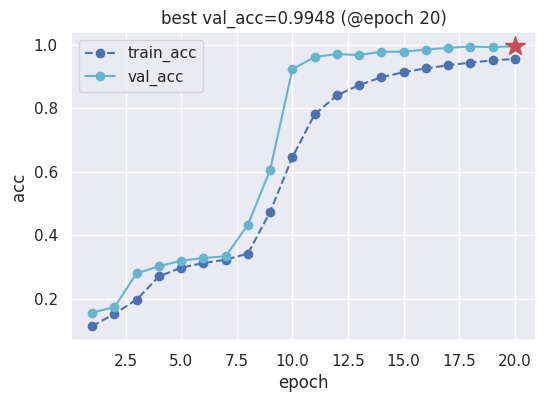

,epoch,train_loss,train_acc,lr,val_loss,val_acc
0,1,1.977321,0.113585,0.000247,1.755978,0.156632
1,2,1.762265,0.153092,0.000494,1.714982,0.173607
2,3,1.674836,0.196856,0.000741,1.497035,0.280076
3,4,1.514607,0.270361,0.000988,1.416408,0.302446
4,5,1.437342,0.297907,0.001235,1.371964,0.319656
5,6,1.397666,0.312578,0.001482,1.351316,0.328412
6,7,1.370715,0.322960,0.001729,1.344830,0.333568
7,8,1.334561,0.342155,0.001976,1.164268,0.433004
8,9,1.113757,0.473350,0.001863,0.879629,0.605075
9,10,0.812943,0.645432,0.001768,0.217181,0.922254


In [45]:
# +定义最终训练使用的标签平滑损失函数
loss_fn = LabelSmoothingLoss(size=len(vocab_y), 
            padding_idx=0, smoothing=0.1)

# +定义指标字典，使用torchmetrics的Accuracy
metrics_dict = {'acc':Accuracy(task='multiclass',num_classes=len(vocab_y))} 
# +定义Noam学习率优化器
optimizer = NoamOpt(net.parameters(),model_size=64)

# +使用KerasModel封装模型、损失函数、指标和优化器
model = KerasModel(net,
                   loss_fn=loss_fn,
                   metrics_dict=metrics_dict,
                   optimizer = optimizer)

# +开始模型训练
model.fit(
    train_data=dl_train,          # +训练数据加载器
    val_data=dl_val,              # +验证数据加载器
    epochs=20,                    # +训练轮数
    ckpt_path='checkpoint',       # +模型 checkpoint 保存路径
    patience=10,                  # +早停耐心值（10轮不提升则停止）
    monitor='val_acc',            # +监控的验证指标
    mode='max',                   # +指标优化方向（最大化val_acc）
    callbacks=None,               # +回调函数（None表示不使用）
    plot=True                     # +是否绘制训练过程的指标曲线
)

In [46]:
# # +继续从 checkpoint 加载模型并训练
# model.fit(
#     train_data=dl_train,
#     val_data=dl_val,
#     epochs=2,          # +再训练 n 个 epoch
#     ckpt_path='checkpoint',
#     patience=10,
#     monitor='val_acc',
#     mode='max',
#     callbacks=None,
#     plot=True
# )


 ## 四，使用模型

 下面使用贪心法进行翻译推理过程。



 和训练过程可以通过掩码遮挡未来token，从而实现一个句子在序列长度方向并行训练不同。



 翻译推理过程只有先翻译了前面的内容，添加到输出中，才能够翻译后面的内容，这个过程是无法在序列维度并行的。



 Decoder&Generator第k位的输出实际上对应的是 已知 输入编码后的memory和前k位Deocder输入(解码序列)



 的情况下解码序列第k+1位取 输出词典中各个词的概率。



 贪心法是获取解码结果的简化方案，工程实践当中一般使用束搜索方法(Beam Search)



 参考：《十分钟读懂Beam Search》 https://zhuanlan.zhihu.com/p/114669778



In [47]:
# +定义贪心解码函数，用于模型推理（翻译）
def greedy_decode(net, src, src_mask, max_len, start_symbol):
    # +模型设为评估模式
    net.eval() 
    # +编码器编码源序列，得到memory（编码特征）
    memory = net.encode(src, src_mask)
    # +初始化输出序列：全为start_symbol（<SOS>），长度为max_len
    ys = torch.full((len(src),max_len),start_symbol,dtype = src.dtype).to(src.device)
    # +逐步生成输出序列（从第0位到max_len-2位，因为第max_len-1位是最后一位）
    for i in range(max_len-1):
        # +解码器解码，结合memory和已生成的序列ys，再通过生成器得到概率分布
        out = net.generator(net.decode(memory, src_mask, 
              ys, tril_mask(ys)))
        # +取当前步输出的最大概率类别，作为下一位的输入
        ys[:,i+1]=out.argmax(dim=-1)[:,i]
    # +返回生成的完整序列
    return ys

# +定义函数：将张量转换为原始单词列表（包含所有特殊符号）
def get_raw_words(tensor,vocab_r) ->"str":
    words = [vocab_r[i] for i in tensor.tolist()]
    return words

# +定义函数：将张量转换为有效单词字符串（去除<SOS>和<EOS>之后的内容）
def get_words(tensor,vocab_r) ->"str":
    s = "".join([vocab_r[i] for i in tensor.tolist()])
    words = s[:s.find('<EOS>')].replace('<SOS>','')
    return words

# +定义函数：将数据移动到模型所在设备（使用accelerator）
def prepare(x,accelerator=model.accelerator):
    return x.to(accelerator.device)


In [48]:
##解码翻译结果
# +获取模型的网络结构
net = model.net
# +模型设为评估模式
net.eval() 
# +将模型移动到指定设备
net = prepare(net)
# +获取一组测试数据（源序列和目标序列）
src,tgt = get_data()
# +将数据移动到指定设备
src,tgt = prepare(src),prepare(tgt)
# +构造带掩码的批次数据（批量大小为1）
mbatch = MaskedBatch(src=src.unsqueeze(dim=0),tgt=tgt.unsqueeze(dim=0))

# +使用贪心解码生成翻译结果
y_pred = greedy_decode(net,mbatch.src,mbatch.src_mask,50,vocab_y["<SOS>"])
# +打印输入序列
print("input:")
print(get_words(mbatch.src[0],vocab_xr),'\n') #标签结果
# +打印真实标签（ground truth）
print("ground truth:")
print(get_words(mbatch.tgt[0],vocab_yr),'\n') #标签结果
# +打印预测结果
print("prediction:")
print(get_words(y_pred[0],vocab_yr)) #解码预测结果，原始标签中<PAD>位置的预测可以忽略



input:
6449446579338+18504138964796 

ground truth:
24953585544134 

prediction:
24953585544134


 ## 五，评估模型

 我们训练过程中监控的acc实际上是字符级别的acc，现在我们来计算样本级别的准确率。

In [49]:
# +从tqdm导入进度条工具
from tqdm.auto import tqdm

# +将模型移动到指定设备
net = prepare(net)
# +创建进度条，迭代200个样本
loop = tqdm(range(1,201))
# +初始化正确预测的样本数
correct = 0
# +遍历样本
for i in loop:
    # +获取一组测试数据
    src,tgt = get_data()
    # +移动数据到指定设备
    src,tgt = prepare(src),prepare(tgt)
    # +构造带掩码的批次数据
    mbatch = MaskedBatch(src=src.unsqueeze(dim=0),tgt=tgt.unsqueeze(dim=0))
    # +贪心解码生成预测结果
    y_pred = greedy_decode(net,mbatch.src,mbatch.src_mask,50,vocab_y["<SOS>"])

    # +获取输入、真实标签、预测结果的有效字符串
    inputs = get_words(mbatch.src[0],vocab_xr) #标签结果
    gt = get_words(mbatch.tgt[0],vocab_yr) #标签结果
    preds = get_words(y_pred[0],vocab_yr) #解码预测结果，原始标签中<PAD>位置的预测可以忽略
    # +如果预测结果与真实标签一致，正确数加1
    if preds==gt:
        correct+=1
    # +更新进度条的后缀信息，显示当前样本级别准确率
    loop.set_postfix(acc = correct/i)
# +打印最终的样本级别准确率
print("acc=",correct/len(loop))
    


  0%|          | 0/200 [00:00<?, ?it/s]

acc= 0.92


 最后我们来可视化一下attention矩阵长啥样。

In [50]:
##先跑一个数据例子
# +获取模型的网络结构
net = model.net
# +模型设为评估模式
net.eval() 
# +将模型移动到指定设备
net = prepare(net)
# +获取一组测试数据
src,tgt = get_data()
# +移动数据到指定设备
src,tgt = prepare(src),prepare(tgt)
# +构造带掩码的批次数据
mbatch = MaskedBatch(src=src.unsqueeze(dim=0),tgt=tgt.unsqueeze(dim=0))


In [51]:
# +贪心解码生成预测结果
y_pred = greedy_decode(net,mbatch.src,mbatch.src_mask,50,vocab_y["<SOS>"])
# +打印输入序列的原始单词列表
print("inputs:")
inputs = get_raw_words(mbatch.src[0],vocab_xr) #标签结果
print(inputs,'\n')

# +打印真实标签的原始单词列表
print("ground truth:")
gt = get_raw_words(mbatch.tgt[0],vocab_yr) #标签结果
print(gt,'\n')

# +打印预测结果的原始单词列表
print("prediction:")
pred = get_raw_words(y_pred[0],vocab_yr) #解码预测结果，原始标签中<PAD>位置的预测可以忽略
print(pred,'\n')


inputs:
['<SOS>', '2', '6', '9', '4', '3', '8', '7', '3', '3', '2', '8', '0', '9', '6', '3', '6', '2', '8', '+', '2', '3', '5', '0', '5', '4', '2', '7', '5', '9', '6', '4', '0', '8', '5', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>'] 

ground truth:
['<SOS>', '2', '6', '9', '6', '7', '3', '7', '8', '7', '5', '5', '6', '9', '2', '7', '7', '1', '3', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>'] 

prediction:
['<SOS>', '2', '6', '9', '6', '7', '3', '7', '8', '7', '5', '5', '6', '9', '2', '7', '7', '1', '3', '<EOS>', '<EOS>', '<EOS>', '3', '<EOS>', '3', '<EOS>', '3', '<EOS>', '4', '<EOS>', '3', '<EOS>', '<EOS>', '<EOS>', '3', '<EOS>', '3', '<EOS>', '<EOS>', '<EOS>', '3', '<

In [52]:
# +提取encoder第0层、第0个样本、第0个head的自注意力矩阵
self_attn_inputs = net.encoder.layers[0].self_attn.attn[0,0,...].tolist() 
# +将注意力矩阵转换为DataFrame，行和列都为输入单词
df_self_attn_inputs = pd.DataFrame(self_attn_inputs,index=inputs,
                                   columns = inputs)
# +过滤掉包含<PAD>的行和列（只保留有效单词）
selected = [i for i in range(len(inputs)) if '<PAD>' not in inputs[i]]
dfxx = df_self_attn_inputs.iloc[selected,selected]



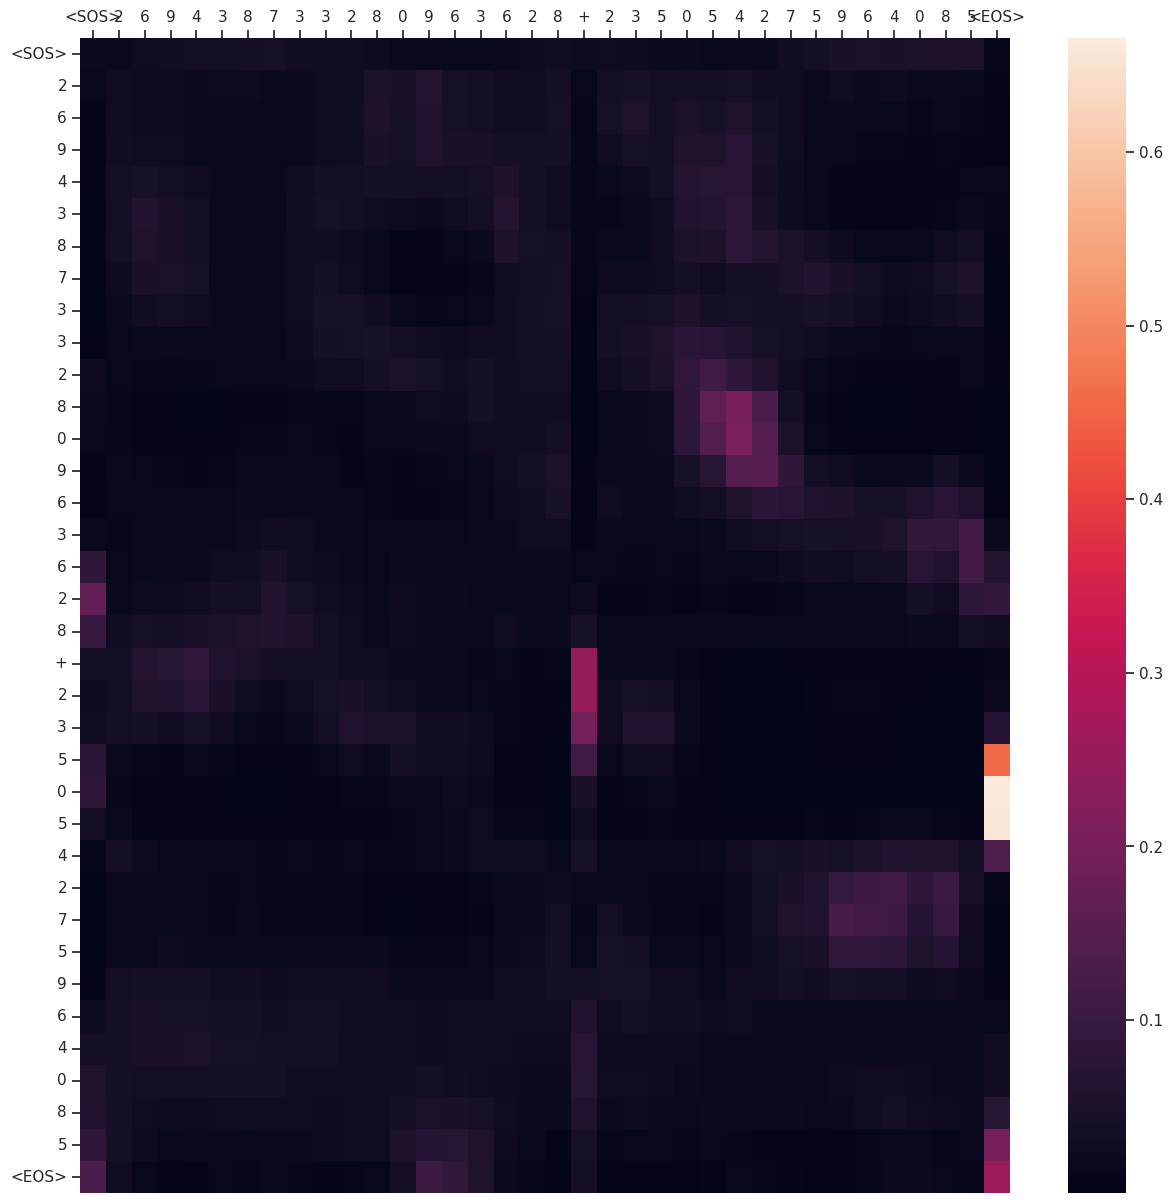

In [53]:
# +导入seaborn库用于绘制热力图
import seaborn as sns 
# +绘制自注意力矩阵热力图
ax = sns.heatmap(dfxx)
#ax.spines['bottom'].set_position(("data", -1))
# +y轴刻度放在左侧
ax.yaxis.tick_left() 
# +x轴刻度放在顶部
ax.xaxis.tick_top() 


In [54]:
# +提取decoder第0层、第0个样本、第0个head的交叉注意力矩阵（encoder-decoder attention）
cross_attn = net.decoder.layers[0].cross_attn.attn[0,0,...].tolist()
# +将交叉注意力矩阵转换为DataFrame，行是输入单词，列是预测单词
df_cross_attn = pd.DataFrame(cross_attn ,index=inputs,
                                   columns = pred)



In [55]:
# +打印交叉注意力矩阵的形状
np.array(cross_attn).shape  


(50, 50)

In [56]:
# +过滤输入单词中包含<PAD>的索引
x_selected = [i for i in range(len(inputs)) if '<PAD>' not in inputs[i]]
# +过滤预测单词中包含<PAD>的索引（这里复用输入的过滤逻辑，保持维度一致）
y_selected = [i for i in range(len(inputs)) if '<PAD>' not in inputs[i]]
# +提取过滤后的交叉注意力矩阵
dfxy = df_cross_attn.iloc[x_selected,y_selected]


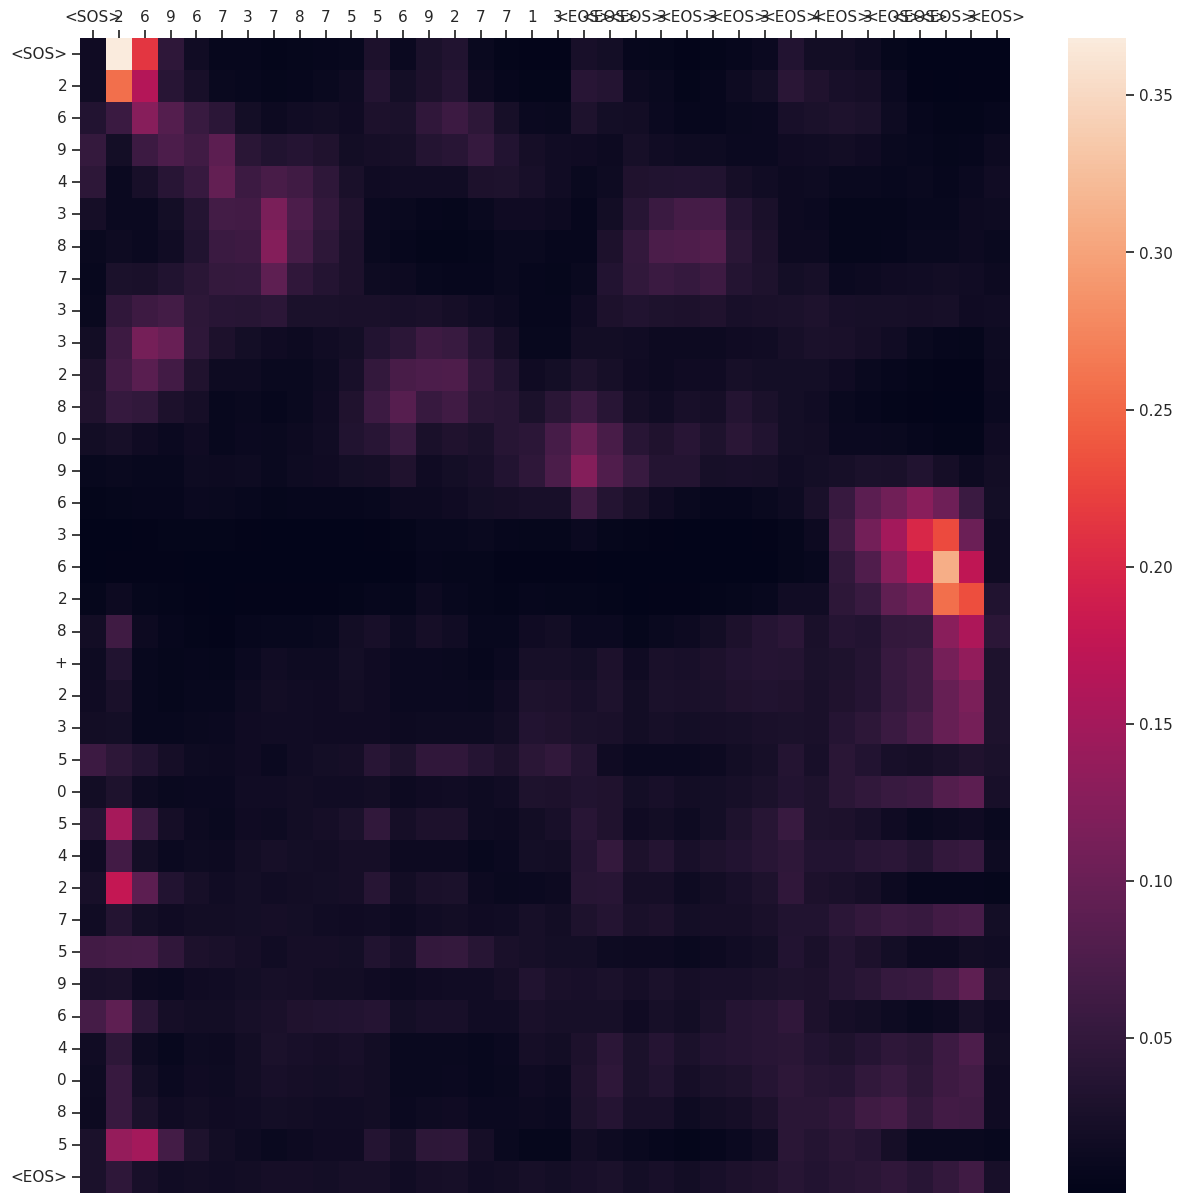

In [57]:
# +导入seaborn库
import seaborn as sns 
# +绘制交叉注意力矩阵热力图
ax = sns.heatmap(dfxy)
#ax.spines['bottom'].set_position(("data", -1))
# +y轴刻度放在左侧
ax.yaxis.tick_left() 
# +x轴刻度放在顶部
ax.xaxis.tick_top()